## Tutorial 3: Benchmarking multiple pipelines

In [2]:
import warnings

import matplotlib.pyplot as plt
import mne
import seaborn as sns
from mne.decoding import CSP
from pyriemann.classification import MDM
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC

import moabb
from moabb.datasets import BNCI2014_001, Zhou2016
from moabb.evaluations import WithinSessionEvaluation
from moabb.paradigms import LeftRightImagery


mne.set_log_level("CRITICAL")
moabb.set_log_level("info")
warnings.filterwarnings("ignore")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Creating Pipelines

We instantiate the three different classiciation pipelines to be considered in the analysis. The object that gathers each pipeline is a dictionary. The first pipeline is the CSP+LDA that we have seen in the previous parts. The other two pipelines rely on Riemannian geometry, using an SVM classification in the tangent space of the covariance matrices estimated from the EEG or a MDM classifier that works directly on covariance matrices.

In [4]:
pipelines = {}
pipelines["csp+lda"] = make_pipeline(CSP(n_components=8), LDA())
pipelines["tgsp+svm"] = make_pipeline(
    Covariances("oas"), TangentSpace(metric="riemann"), SVC(kernel="linear")
)
pipelines["MDM"] = make_pipeline(Covariances("oas"), MDM(metric="riemann"))



In [5]:
datasets = [BNCI2014_001(), Zhou2016()]
subj = [1, 2, 3]
for d in datasets:
    d.subject_list = subj
paradigm = LeftRightImagery()
evaluation = WithinSessionEvaluation(
    paradigm=paradigm, datasets=datasets, overwrite=False
)
results = evaluation.process(pipelines)

2026-07-15 15:21:18,002 INFO MainThread moabb.evaluations.base tgsp+svm | BNCI2014-001 | 1 | 1test: Score 0.970
2026-07-15 15:21:18,003 INFO MainThread moabb.evaluations.base MDM | BNCI2014-001 | 1 | 1test: Score 0.944
2026-07-15 15:21:18,003 INFO MainThread moabb.evaluations.base tgsp+svm | BNCI2014-001 | 1 | 0train: Score 0.935
2026-07-15 15:21:18,003 INFO MainThread moabb.evaluations.base MDM | BNCI2014-001 | 1 | 0train: Score 0.947
2026-07-15 15:21:18,003 INFO MainThread moabb.evaluations.base tgsp+svm | BNCI2014-001 | 3 | 1test: Score 0.998
2026-07-15 15:21:18,003 INFO MainThread moabb.evaluations.base MDM | BNCI2014-001 | 3 | 1test: Score 0.993
2026-07-15 15:21:18,004 INFO MainThread moabb.evaluations.base tgsp+svm | BNCI2014-001 | 3 | 0train: Score 0.993
2026-07-15 15:21:18,004 INFO MainThread moabb.evaluations.base MDM | BNCI2014-001 | 3 | 0train: Score 0.986
2026-07-15 15:21:18,004 INFO MainThread moabb.evaluations.base tgsp+svm | BNCI2014-001 | 2 | 0train: Score 0.712
2026-07

## Plotting Results

The following plot shows a comparison of the three classification pipelines for each subject of each dataset.

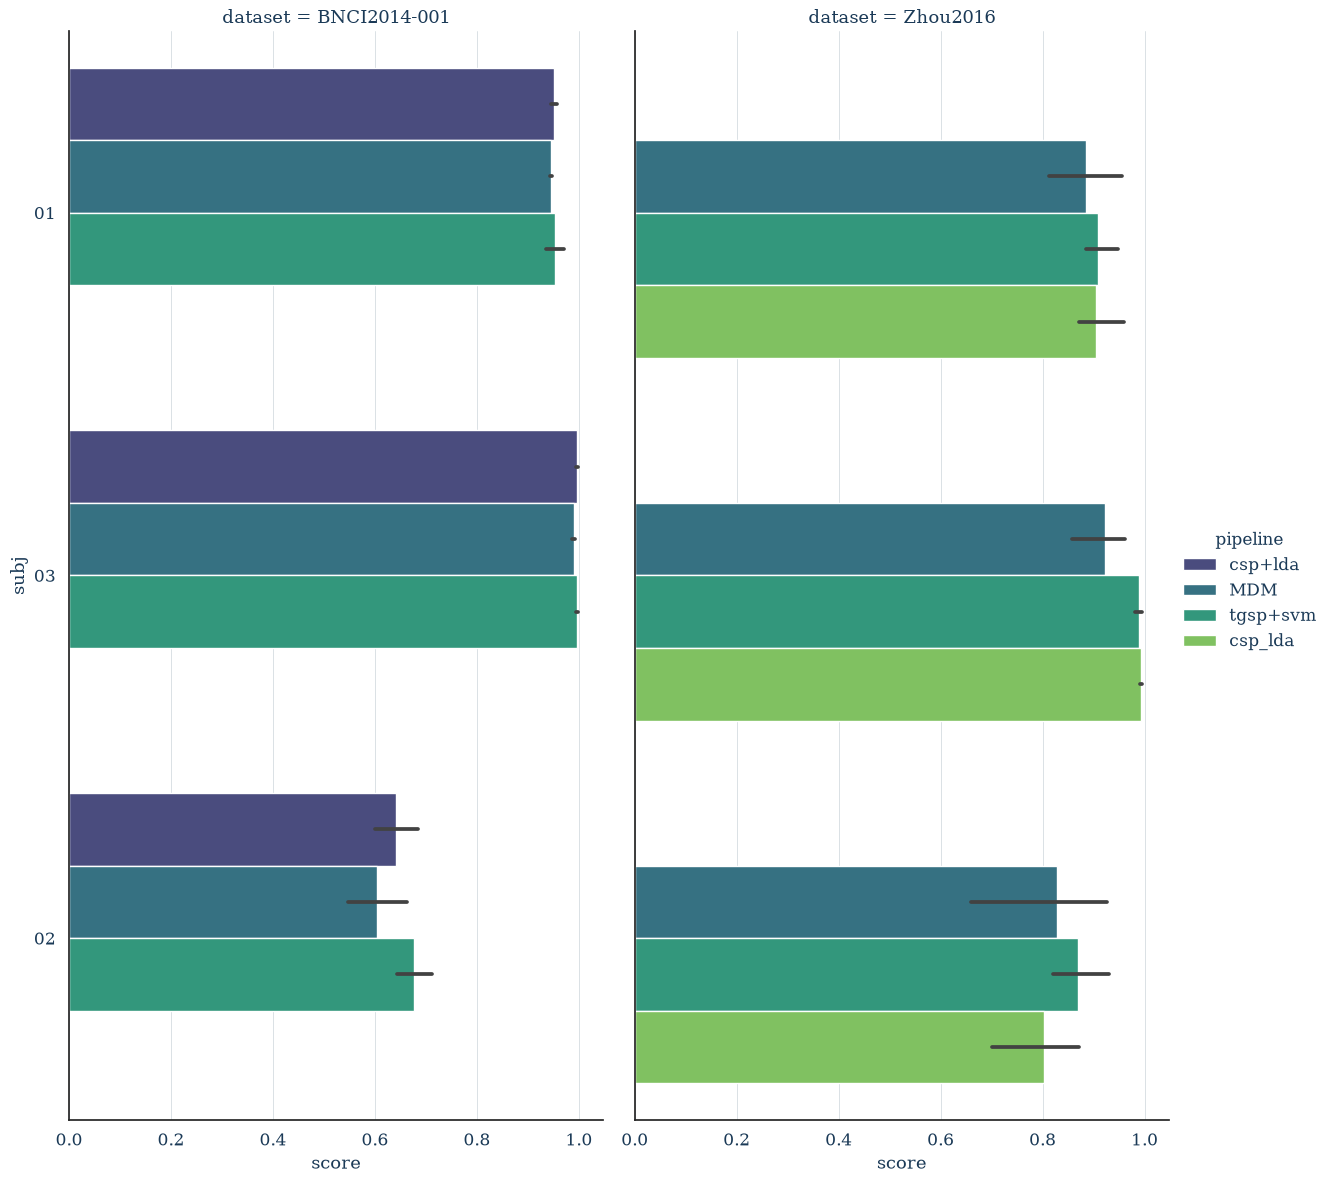

In [6]:
results["subj"] = [str(resi).zfill(2) for resi in results["subject"]]
g = sns.catplot(
    kind="bar",
    x="score",
    y="subj",
    hue="pipeline",
    col="dataset",
    height=12,
    aspect=0.5,
    data=results,
    orient="h",
    palette="viridis",
)
plt.show()